Analisis exploratorio de datos

Credit Card Fraud Detection Predictive Models

Este conjunto de datos contiene transacciones realizadas con tarjetas de crédito en septiembre de 2013 por titulares de tarjetas europeos. El dataset presenta transacciones ocurridas en un periodo de dos días, donde se identifican 492 fraudes de un total de 284,807 transacciones. El conjunto de datos está altamente desequilibrado: la clase positiva (fraudes) representa solo el 0.172% de todas las transacciones.

Contiene únicamente variables numéricas de entrada que son el resultado de una transformación PCA (Análisis de Componentes Principales). Debido a problemas de confidencialidad, no se proporcionan las características originales ni información adicional de contexto sobre los datos.

Descripción de las Variables

V1, V2, ... V28: Son los componentes principales obtenidos mediante PCA.

Time (Tiempo): Contiene los segundos transcurridos entre cada transacción y la primera transacción del conjunto de datos.

Amount (Monto): Es el monto de la transacción. Esta característica puede utilizarse para el aprendizaje sensible al costo dependiente del ejemplo (example-dependent cost-sensitive learning).

Class (Clase): Es la variable de respuesta; toma el valor 1 en caso de fraude y 0 en cualquier otro caso.


Preparación y Carga de Datos

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import os

# Resolver la ruta del archivo CSV (el notebook está en notebooks/)
# El archivo de datos está en ../data/raw/creditcard.csv
data_path = Path("../data/raw/creditcard.csv")

# Cargar el dataset
df = pd.read_csv(data_path)

# Visualización inicial
print(f"Dataset cargado desde: {data_path.resolve()}")
print(f"Forma del dataset: {df.shape}")
print("\nPrimeras filas:")
print(df.head())
print("\nInformación del dataset:")
print(df.info())

Dataset cargado desde: /Users/diegofernandonunezdiaz/developer/entregaProyecto/UdeMedellin-S2-AANube/data/raw/creditcard.csv
Forma del dataset: (284807, 31)

Primeras filas:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.3870

Limpieza de Datos

Valores Nulos: Verificar si existen celdas vacías.

Duplicados: Eliminar registros repetidos que puedan sesgar el modelo.

In [11]:
# Verificación de nulos
print(f"Valores nulos:\n{df.isnull().sum().sum()}")

# Manejo de duplicados
duplicates = df.duplicated().sum()
print(f"Registros duplicados: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicados eliminados.")

Valores nulos:
0
Registros duplicados: 1081
Duplicados eliminados.


Análisis Exploratorio de Datos (EDA)

A. Desequilibrio de Clases

Este es el aspecto más crítico. El fraude suele representar menos del 0.2% de las transacciones.


/var/folders/rj/1mp3qrxx189flshbl9vynrcr0000gn/T/ipykernel_28738/2375860903.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette="viridis")


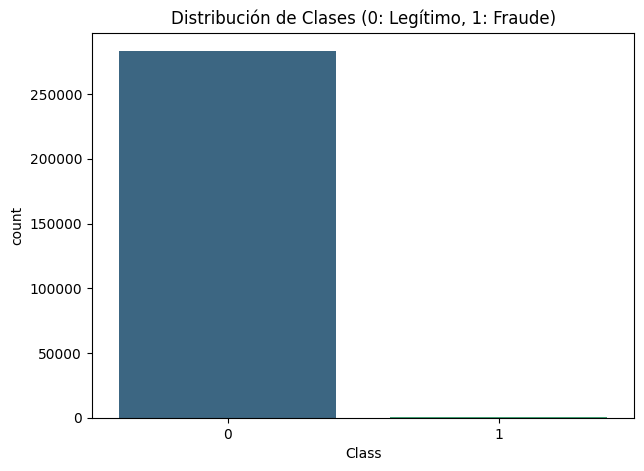

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Class", data=df, palette="viridis")
plt.title("Distribución de Clases (0: Legítimo, 1: Fraude)")
plt.show()

print(df["Class"].value_counts(normalize=True) * 100)

Análisis de "Time" y "Amount"
A diferencia de las variables Vn, Time y Amount no están escaladas y requieren inspección.

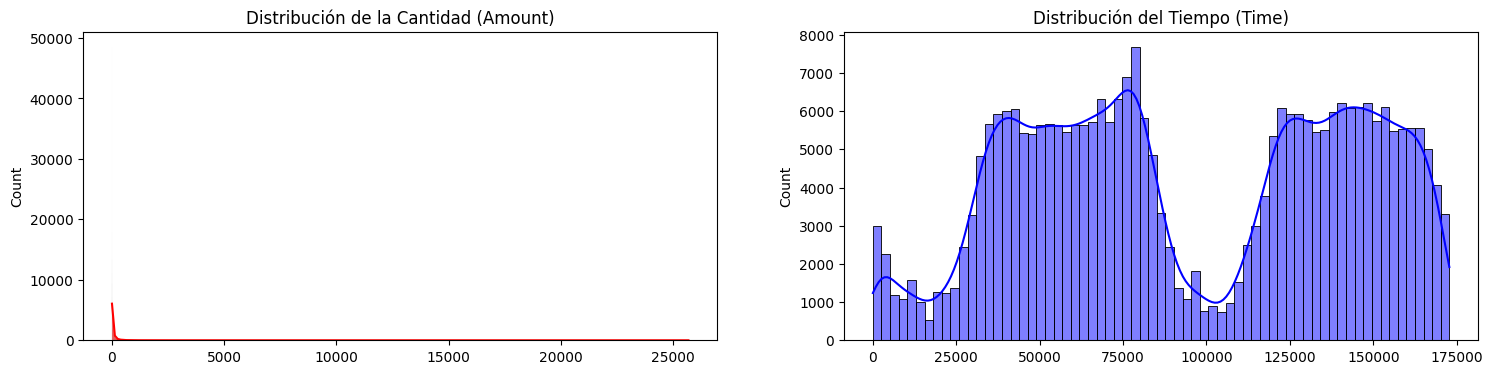

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

amount_val = df["Amount"].values
time_val = df["Time"].values

sns.histplot(amount_val, ax=ax[0], color="r", kde=True)
ax[0].set_title("Distribución de la Cantidad (Amount)")

sns.histplot(time_val, ax=ax[1], color="b", kde=True)
ax[1].set_title("Distribución del Tiempo (Time)")

plt.show()

Matriz de Correlación
Permite identificar qué componentes Vn tienen mayor influencia en la variable objetivo Class

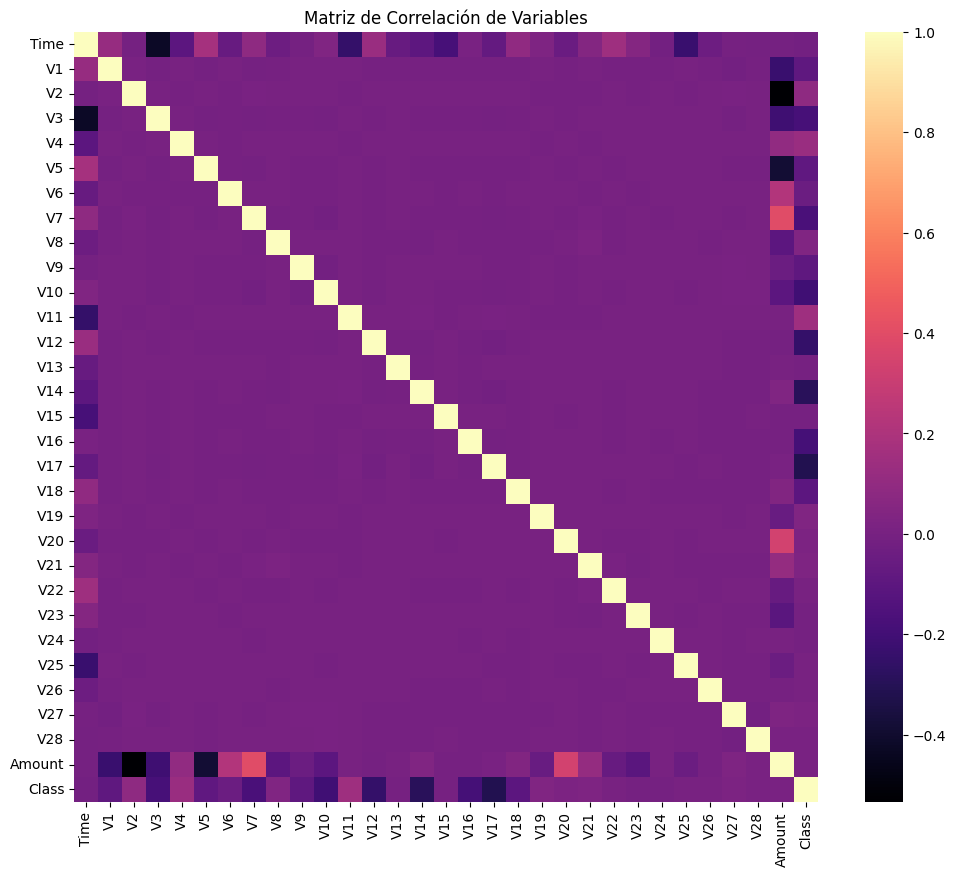

In [14]:
plt.figure(figsize=(12, 10))
matrix = df.corr()
sns.heatmap(matrix, cmap="magma", annot=False)
plt.title("Matriz de Correlación de Variables")
plt.show()

Transformación de Características

Para que algoritmos como SVM o K-Nearest Neighbors funcionen correctamente, es necesario escalar las columnas Time y Amount, ya que sus magnitudes son muy superiores a las variables transformadas por PCA.

Se recomienda usar StandardScaler o RobustScaler (este último es preferible si hay muchos valores atípicos en Amount):

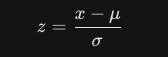
​

In [ ]:
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

df["scaled_amount"] = rob_scaler.fit_transform(df["Amount"].values.reshape(-1, 1))
df["scaled_time"] = rob_scaler.fit_transform(df["Time"].values.reshape(-1, 1))

# Eliminamos las originales
df.drop(["Time", "Amount"], axis=1, inplace=True)

Hallazgos Clave para el Modelado

Altamente Desbalanceado: Se requerirán técnicas como SMOTE (oversampling) o Under-sampling para entrenar el modelo.

Métricas de Evaluación: El Accuracy no es útil aquí. Deberás enfocarte en AUPRC (Area Under the Precision-Recall Curve) y en la Matriz de Confusión (específicamente en los Falsos Negativos).

Outliers: Algunas variables Vn
​	
  presentan valores atípicos extremos que podrían necesitar un truncamiento si se utilizan modelos sensibles a la varianza.